In [1]:
#Task 5
print("Task 5")

Task 5


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, roc_curve, auc)
#########################################################
#Step 1:Loading Dataset
####################################################
data = pd.read_csv(r'C:\Users\Hp\Downloads\bank.csv', sep=',')

# Rename target column to 'y' for consistency
data.rename(columns={'deposit': 'y'}, inplace=True)

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print(data.head())
print("\nMissing Values:\n", data.isnull().sum())

Shape: (11162, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome    y  
0    5   may      1042         1     -1         0  unknown  yes  
1    5   may      1467         1     -1         0  unknown  yes  
2    5   may      1389         1     -1         0  unknown  yes  
3    5   may       579         1     -1         0  u

In [1]:

# ============================================================
# Step 2. DATA EXPLORATION & VISUALIZATION
# ============================================================
print("\nTarget (y) Distribution:")
print(data['y'].value_counts())

# Pre-compute acceptance rates BEFORE encoding
job_acceptance     = data.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
marital_acceptance = data.groupby('marital')['y'].apply(lambda x: (x=='yes').mean()*100)
edu_acceptance     = data.groupby('education')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Bank Marketing Dataset',
             fontsize=16, fontweight='bold')

# Plot 1: Loan Acceptance Count
data['y'].value_counts().plot(kind='bar', ax=axes[0,0],
                               color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('Loan Acceptance Distribution')
axes[0,0].set_xlabel('Accepted Loan')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['No','Yes'], rotation=0)

# Plot 2: Age Distribution by Outcome
for label, grp in data.groupby('y')['age']:
    grp.plot(kind='kde', ax=axes[0,1], label=label)
axes[0,1].set_title('Age Distribution by Loan Acceptance')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Plot 3: Job vs Acceptance Rate
job_acceptance.plot(kind='bar', ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Loan Acceptance Rate by Job (%)')
axes[0,2].set_xlabel('Job Type')
axes[0,2].set_ylabel('Acceptance Rate (%)')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: Marital Status vs Acceptance
marital_acceptance.plot(kind='bar', ax=axes[1,0],
                        color=['tomato','steelblue','seagreen'], edgecolor='black')
axes[1,0].set_title('Acceptance Rate by Marital Status (%)')
axes[1,0].set_xlabel('Marital Status')
axes[1,0].set_ylabel('Acceptance Rate (%)')
axes[1,0].tick_params(axis='x', rotation=0)

# Plot 5: Balance vs Acceptance
sns.boxplot(data=data, x='y', y='balance',
            palette={'no':'steelblue','yes':'tomato'}, ax=axes[1,1])
axes[1,1].set_title('Account Balance by Loan Acceptance')
axes[1,1].set_xlabel('Accepted Loan')
axes[1,1].set_ylabel('Balance ($)')

# Plot 6: Education vs Acceptance
edu_acceptance.plot(kind='bar', ax=axes[1,2], color='mediumpurple', edgecolor='black')
axes[1,2].set_title('Acceptance Rate by Education (%)')
axes[1,2].set_xlabel('Education Level')
axes[1,2].set_ylabel('Acceptance Rate (%)')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


Target (y) Distribution:


NameError: name 'data' is not defined

In [14]:
# ============================================================
#  Step 3: ENCODING CATEGORICAL FEATURES
# ============================================================
data_encoded = data.copy()
# Label encode binary columns
le = LabelEncoder()
for col in ['default', 'housing', 'loan', 'y']:
    if col in data_encoded.columns:
        data_encoded[col] = le.fit_transform(data_encoded[col])

# One-Hot encode multi-class columns
ohe_cols = [c for c in ['job','marital','education','contact','month','poutcome']
            if c in data_encoded.columns]
data_encoded = pd.get_dummies(data_encoded, columns=ohe_cols, drop_first=True)

# Fix boolean dtype (pandas 2.x)
bool_cols = data_encoded.select_dtypes(include='bool').columns
data_encoded[bool_cols] = data_encoded[bool_cols].astype(int)

print("\nShape after encoding:", data_encoded.shape)




Shape after encoding: (11162, 43)


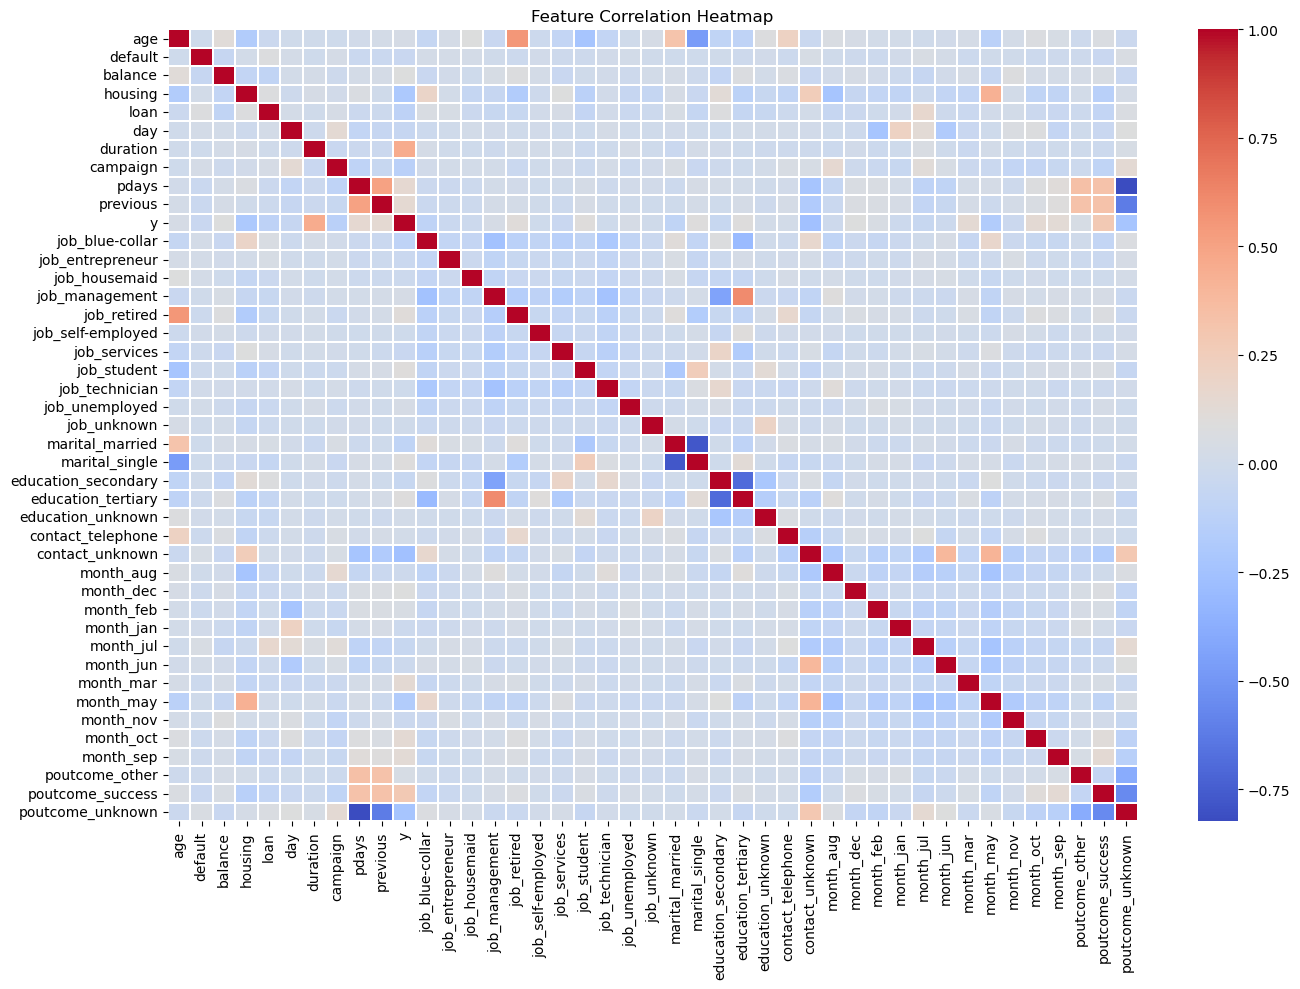

In [15]:
# ============================================================
#Step 4:  Using CORRELATION HEATMAP (for numeric features only)
# ============================================================
plt.figure(figsize=(14, 10))
sns.heatmap(data_encoded.select_dtypes(include=[np.number]).corr(),
            annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()



In [16]:
# ============================================================
# Step 5 Using  SPLIT FEATURES AND TARGET
# ============================================================
X = data_encoded.drop('y', axis=1)
y = data_encoded['y']

print(f"\nClass distribution:\n{y.value_counts()}")
print(f"Acceptance rate: {y.mean()*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")




Class distribution:
y
0    5873
1    5289
Name: count, dtype: int64
Acceptance rate: 47.38%
Training: 8929 | Test: 2233


In [17]:
# ============================================================
# Step 6 Using LOGISTIC REGRESSION
# ============================================================
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\n========== LOGISTIC REGRESSION ==========")
print(f"Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(classification_report(y_test, lr_pred, target_names=['Rejected','Accepted']))
# ============================================================
# Using  DECISION TREE CLASSIFIER
# ============================================================
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\n========== DECISION TREE ==========")
print(f"Accuracy: {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(classification_report(y_test, dt_pred, target_names=['Rejected','Accepted']))




========== LOGISTIC REGRESSION ==========
Accuracy: 82.58%
              precision    recall  f1-score   support

    Rejected       0.84      0.83      0.83      1175
    Accepted       0.81      0.82      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233


========== DECISION TREE ==========
Accuracy: 80.39%
              precision    recall  f1-score   support

    Rejected       0.83      0.79      0.81      1175
    Accepted       0.78      0.82      0.80      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


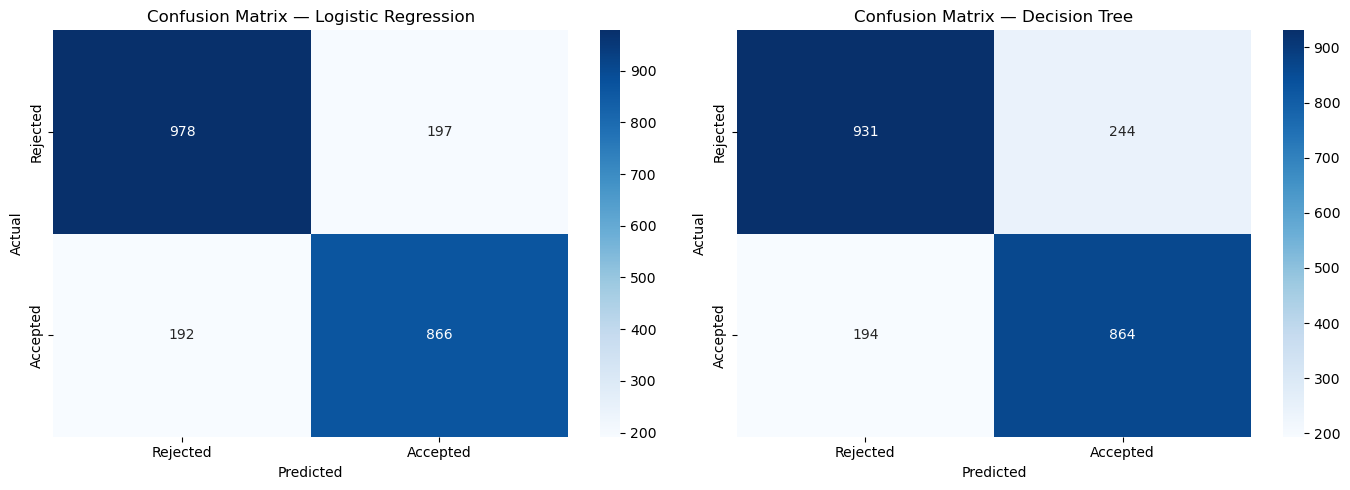

In [18]:
# ============================================================
# Step 6 Using  CONFUSION MATRICES — For BOTH MODELS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes,
                             [lr_pred, dt_pred],
                             ['Logistic Regression','Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected','Accepted'],
                yticklabels=['Rejected','Accepted'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()



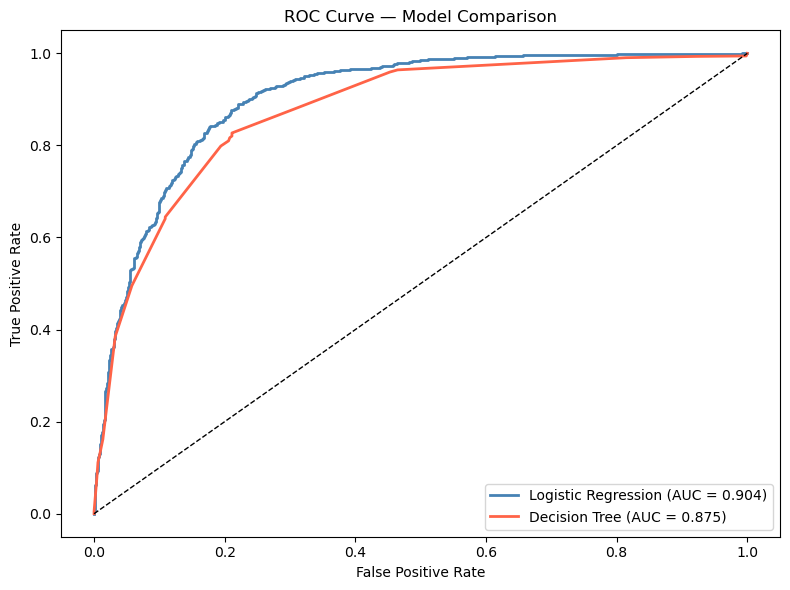

In [19]:
# ============================================================
# Step 9 Using ROC CURVE COMPARISON
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, color in [
    (lr_model, 'Logistic Regression', 'steelblue'),
    (dt_model, 'Decision Tree',       'tomato')
]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



C:\Users\Hp\AppData\Local\Temp\ipykernel_12668\3932549188.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')


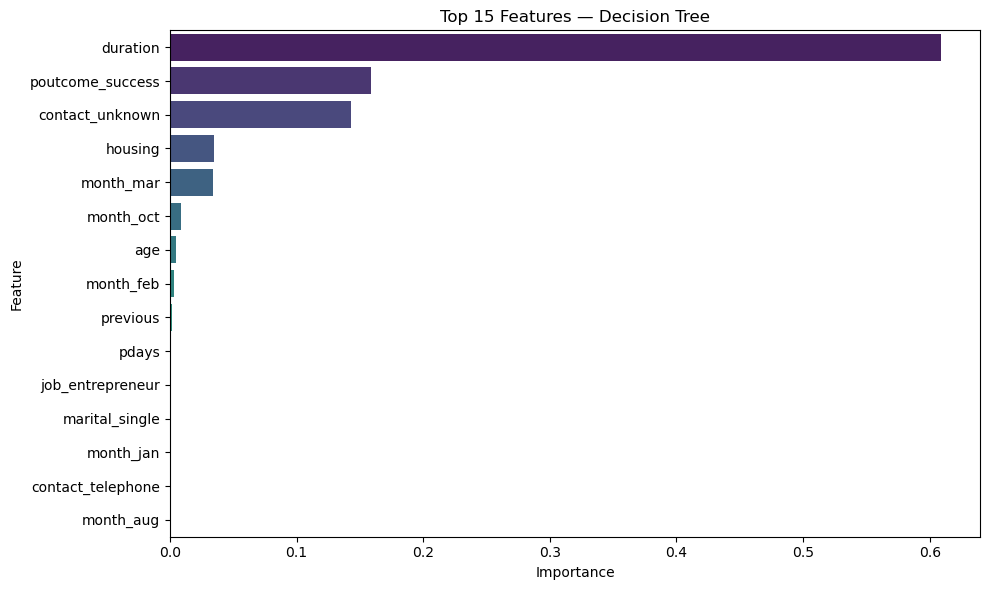

In [20]:
# ============================================================
#  Step 10 :FEATURE IMPORTANCE (Decision Tree)
# ============================================================
feat_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Features — Decision Tree')
plt.tight_layout()
plt.show()



In [21]:
# ============================================================
# Step 11 BUSINESS INSIGHTS
# ============================================================
print("\n========== BUSINESS INSIGHTS ==========")

print("\n Top 5 Jobs by Acceptance Rate:")
print(job_acceptance.head())

print("\n Acceptance Rate by Marital Status:")
print(marital_acceptance.sort_values(ascending=False))

print("\n Acceptance Rate by Education:")
print(edu_acceptance)

print("\n Average Balance — Accepted vs Rejected:")
print(data.groupby('y')['balance'].mean())

print("\n Average Age — Accepted vs Rejected:")
print(data.groupby('y')['age'].mean())





========== BUSINESS INSIGHTS ==========

 Top 5 Jobs by Acceptance Rate:
job
student       74.722222
retired       66.323907
unemployed    56.582633
management    50.701481
unknown       48.571429
Name: y, dtype: float64

 Acceptance Rate by Marital Status:
marital
single      54.349062
divorced    48.105182
married     43.378995
Name: y, dtype: float64

 Acceptance Rate by Education:
education
tertiary     54.106804
unknown      50.704225
secondary    44.740687
primary      39.400000
Name: y, dtype: float64

 Average Balance — Accepted vs Rejected:
y
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64

 Average Age — Accepted vs Rejected:
y
no     40.837391
yes    41.670070
Name: age, dtype: float64
